# Klasifikasi Digit MNIST

## 0.1 Setup

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import time

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110

## 0.2 Load & Eksplorasi Data

In [28]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

print("X Shape :", X.shape)
print("y Shape :", y.shape)
print("X dtype :", X.dtype)
print("y dtype :", y.dtype)
print("Rentang nilai pixel:", X.min(), "-", X.max())

X Shape : (70000, 784)
y Shape : (70000,)
X dtype : int64
y dtype : object
Rentang nilai pixel: 0 - 255


In [29]:
y = y.astype(np.int64)

X_sub, _, y_sub, _ = train_test_split(
    X, y,
    train_size=10000,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    train_size=8000,
    stratify=y_sub,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (8000, 784) (8000,)
Test : (2000, 784) (2000,)


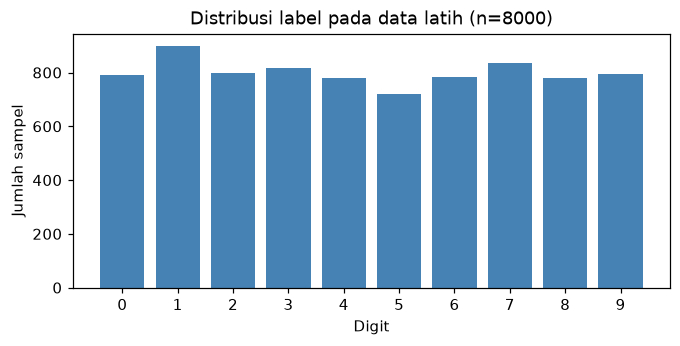

Min: 722 | Max: 900


In [30]:
labels, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(7, 3))
plt.bar(labels, counts, color='steelblue')
plt.xticks(labels)
plt.xlabel("Digit")
plt.ylabel("Jumlah sampel")
plt.title("Distribusi label pada data latih (n=8000)")
plt.show()

print("Min:", counts.min(), "| Max:", counts.max())

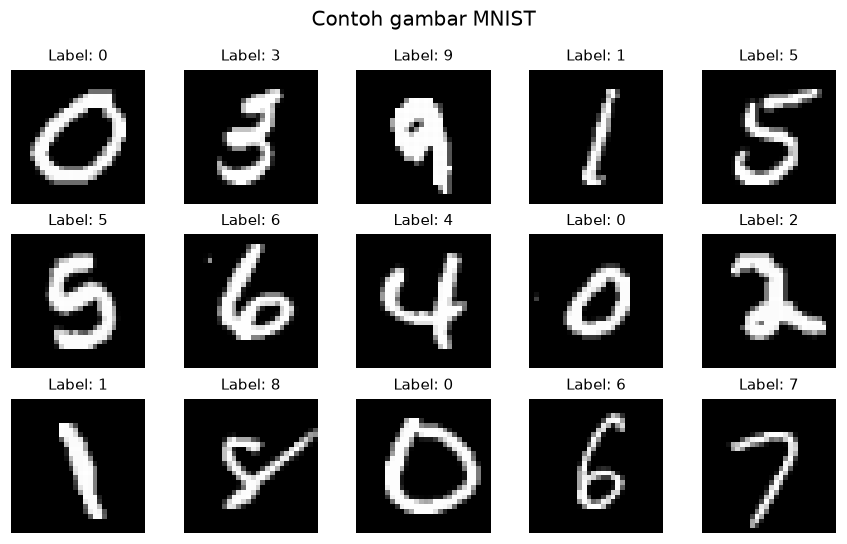

In [31]:
fig, axes = plt.subplots(3, 5, figsize=(8, 5))

for ax, img, label in zip(axes.ravel(), X_train, y_train):
    ax.imshow(img.reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {label}", fontsize=10)
    ax.axis('off')

plt.suptitle("Contoh gambar MNIST", fontsize=13)
plt.tight_layout()
plt.show()

## 0.3 Gambar sebagai Vektor

Komputer tidak "melihat" gambar seperti kita. Yang dilihatnya cuma matriks angka di sini, 28×28 nilai intensitas dari 0 (hitam) sampai 255 (putih). Kalau matriks ini diratakan (flatten) jadi satu baris, kita dapat vektor 784 angka. Setiap gambar MNIST, dengan cara ini, jadi satu titik di ruang 784 dimensi.

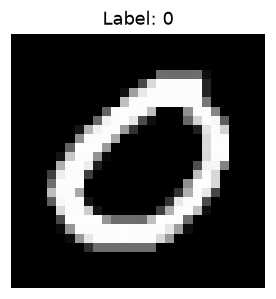

Gambar ini adalah matriks 28x28, label=0
[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  4  4  4  4  4  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  8 10 10 10 10 10  1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  6  9 10 10 10 10 10 10  1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  7 10 10 10 10 10 10 10 10  4  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  3 10 10 10 10  7  0  0  0  5 10 10  5  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  4  9 10 10  9  3  0  0  0  0  4  8 10  9  3  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  7  9 10 10  6  2  0  0  0  0  0  0  1  9 10  8  0  0  0  0]
 [

In [32]:
np.set_printoptions(linewidth=200)

idx = 0
img = X_train[idx].reshape(28, 28)
label = y_train[idx]

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(img, cmap='gray')
ax.set_title(f"Label: {label}")
ax.axis('off')
plt.show()

print(f"Gambar ini adalah matriks 28x28, label={label}")
print((img // 25).astype(int))

In [33]:
flat = img.flatten()

print("Bentuk sebelum flatten:", img.shape)
print("Bentuk sesudah flatten:", flat.shape)
print("\n20 elemen pertama:")
print(flat[:20])

Bentuk sebelum flatten: (28, 28)
Bentuk sesudah flatten: (784,)

20 elemen pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 0.4 Normalisasi

Nilai pixel diskalakan dari 0–255 menjadi 0–1.

In [34]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Rentang sebelum: 0-255")
print("Rentang sesudah:", X_train.min(), "-", X_train.max())

Rentang sebelum: 0-255
Rentang sesudah: 0.0 - 1.0


## 0.5 Baseline

In [35]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

hasil = {} 

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
akurasi_dummy = accuracy_score(y_test, y_pred_dummy)
print(f"Akurasi baseline (dummy): {akurasi_dummy:.4f}")

hasil['Dummy'] = {'akurasi': akurasi_dummy, 'waktu_train': None, 'waktu_predict': None}

Akurasi baseline (dummy): 0.1125


---
# K-Nearest Neighbors


## 1.1 Training & Prediksi Dasar

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

t0 = time.perf_counter()
knn.fit(X_train, y_train)
waktu_train_knn = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_knn = knn.predict(X_test)
waktu_predict_knn = time.perf_counter() - t0

akurasi_knn = accuracy_score(y_test, y_pred_knn)

print(f"Akurasi KNN (k=3)  : {akurasi_knn:.4f}")
print(f"Waktu training     : {waktu_train_knn:.4f} detik")
print(f"Waktu prediksi     : {waktu_predict_knn:.4f} detik")

hasil['KNN (k=3)'] = {
    'akurasi': akurasi_knn,
    'waktu_train': waktu_train_knn,
    'waktu_predict': waktu_predict_knn
}

Akurasi KNN (k=3)  : 0.9475
Waktu training     : 0.0027 detik
Waktu prediksi     : 0.1038 detik


## 1.2 Demo Visual: Tetangga Terdekat

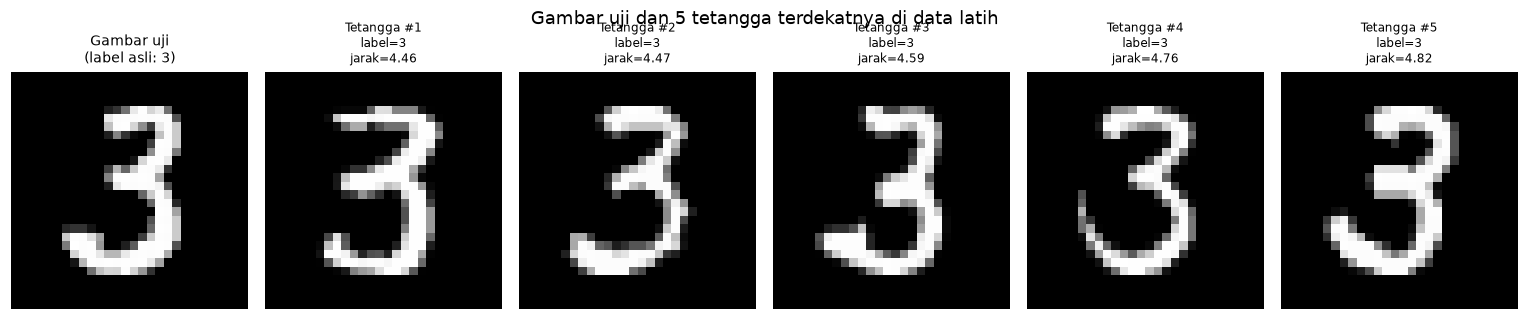

In [37]:
idx_contoh = 7 

distances, indices = knn.kneighbors(X_test[idx_contoh:idx_contoh+1], n_neighbors=5)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))

axes[0].imshow(X_test[idx_contoh].reshape(28, 28), cmap='gray')
axes[0].set_title(f"Gambar uji\n(label asli: {y_test[idx_contoh]})", fontsize=9)
axes[0].axis('off')

for i in range(5):
    train_idx = indices[0][i]
    axes[i+1].imshow(X_train[train_idx].reshape(28, 28), cmap='gray')
    axes[i+1].set_title(f"Tetangga #{i+1}\nlabel={y_train[train_idx]}\njarak={distances[0][i]:.2f}", fontsize=8)
    axes[i+1].axis('off')

plt.suptitle("Gambar uji dan 5 tetangga terdekatnya di data latih", fontsize=12)
plt.tight_layout()
plt.show()

## 1.3 Analisis Error

Total salah: 105 dari 2000 (5.2%)


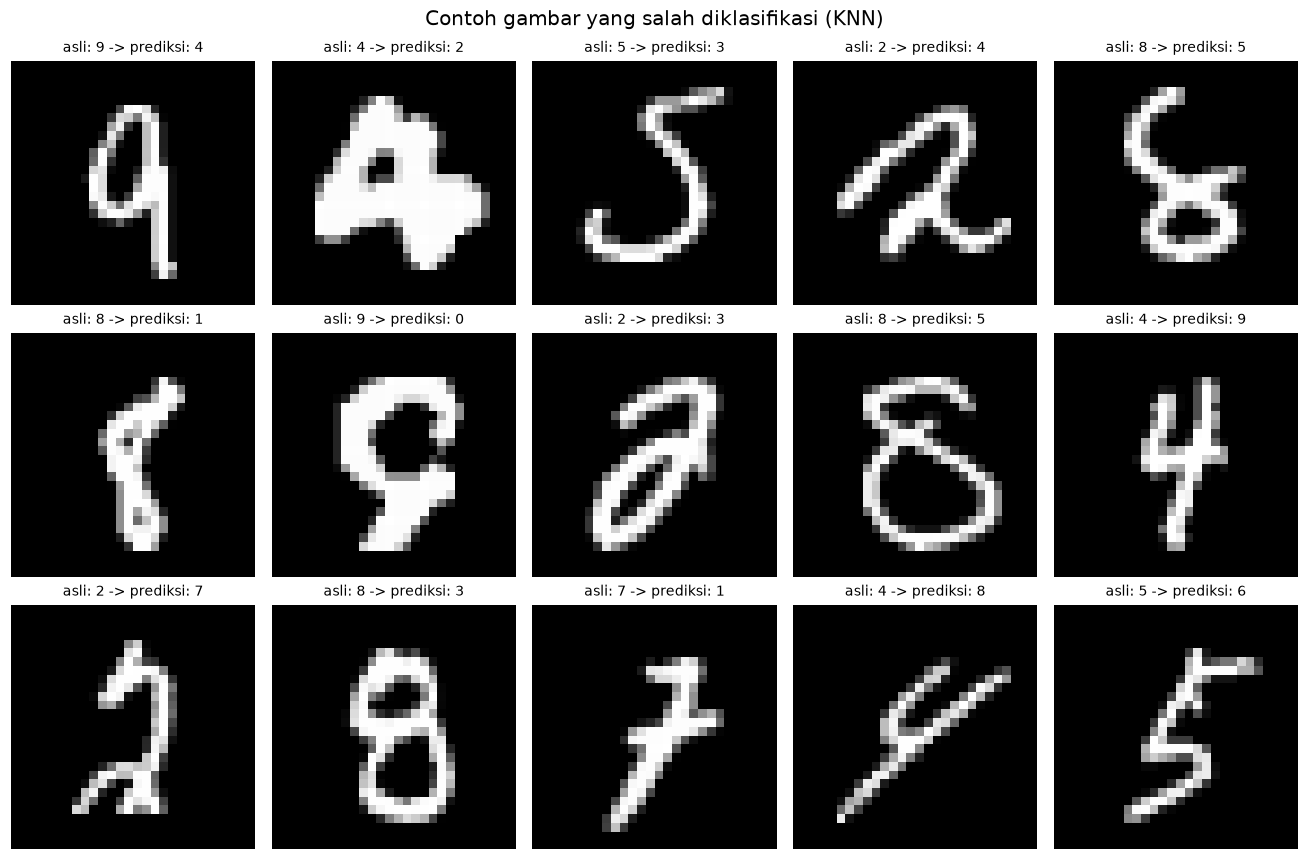

In [38]:
salah_idx = np.where(y_pred_knn != y_test)[0]
print(f"Total salah: {len(salah_idx)} dari {len(y_test)} ({len(salah_idx)/len(y_test):.1%})")

n_tampil = 15
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for ax, idx in zip(axes.ravel(), salah_idx[:n_tampil]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"asli: {y_test[idx]} -> prediksi: {y_pred_knn[idx]}", fontsize=9)
    ax.axis('off')

plt.suptitle("Contoh gambar yang salah diklasifikasi (KNN)", fontsize=13)
plt.tight_layout()
plt.show()

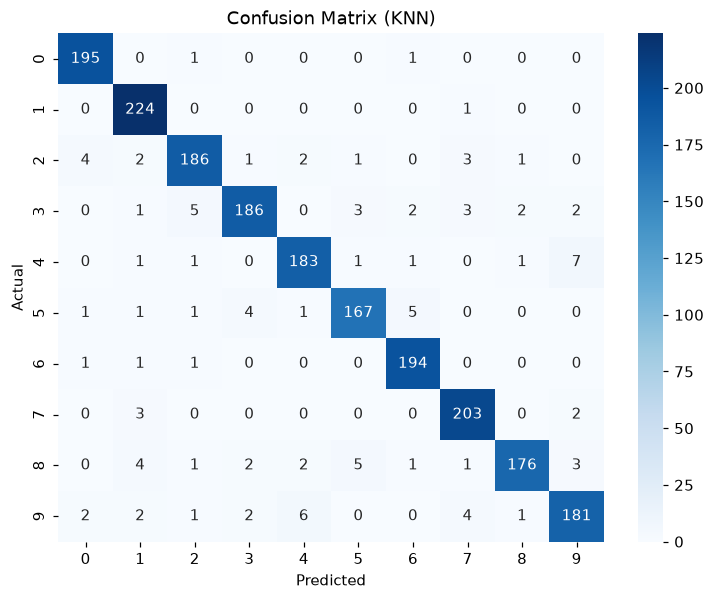

In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_knn)

import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 1.4 Ringkasan KNN

In [40]:
import pandas as pd

df_hasil_knn = pd.DataFrame(hasil).T
df_hasil_knn = df_hasil_knn.rename(columns={
    'akurasi': 'Akurasi',
    'waktu_train': 'Waktu Training (s)',
    'waktu_predict': 'Waktu Prediksi (s)'
})
df_hasil_knn

,Akurasi,Waktu Training (s),Waktu Prediksi (s)
Dummy,0.1125,NaN,NaN
KNN (k=3),0.9475,0.002732,0.103782


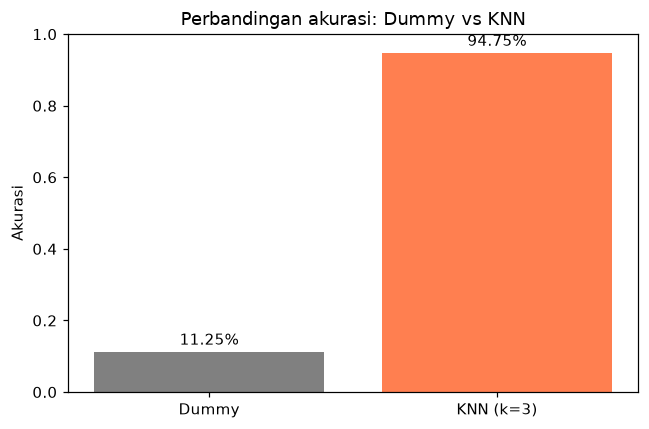

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_hasil_knn.index, df_hasil_knn['Akurasi'], color=['gray', 'coral'])
ax.set_ylabel("Akurasi")
ax.set_ylim(0, 1)
ax.set_title("Perbandingan akurasi: Dummy vs KNN")
for i, v in enumerate(df_hasil_knn['Akurasi']):
    ax.text(i, v + 0.02, f"{v:.2%}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
# Logistic Regression


## 2.1 Training & Prediksi Dasar

In [42]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)

t0 = time.perf_counter()
logreg.fit(X_train, y_train)
waktu_train_logreg = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_logreg = logreg.predict(X_test)
waktu_predict_logreg = time.perf_counter() - t0

akurasi_logreg = accuracy_score(y_test, y_pred_logreg)

print(f"Akurasi Logistic Regression: {akurasi_logreg:.4f}")
print(f"Waktu training     : {waktu_train_logreg:.4f} detik")
print(f"Waktu prediksi     : {waktu_predict_logreg:.4f} detik")

hasil['Logistic Regression'] = {
    'akurasi': akurasi_logreg,
    'waktu_train': waktu_train_logreg,
    'waktu_predict': waktu_predict_logreg
}

Akurasi Logistic Regression: 0.8975
Waktu training     : 8.3038 detik
Waktu prediksi     : 0.0021 detik


## 2.2 Visualisasi Koefisien

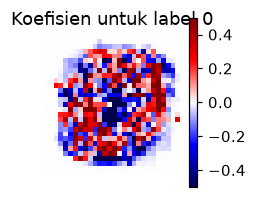

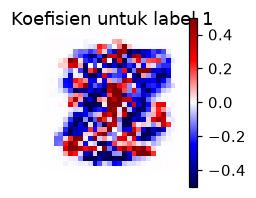

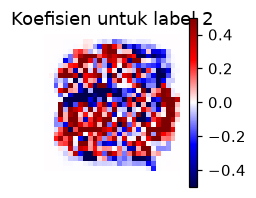

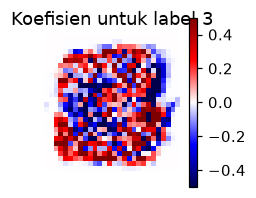

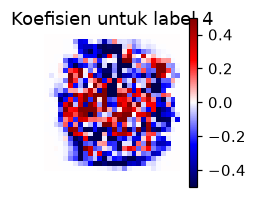

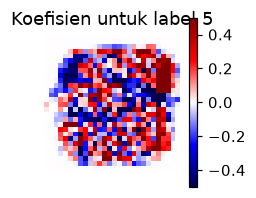

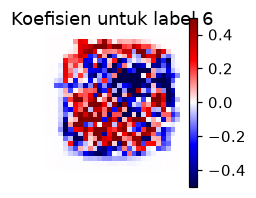

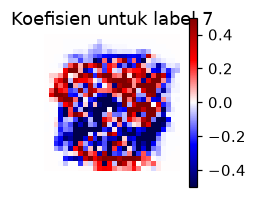

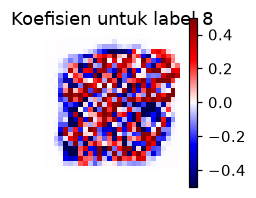

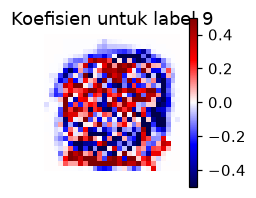

In [43]:
for baris in range(10):
    plt.figure(figsize=(2, 2))
    plt.imshow(logreg.coef_[baris].reshape(28, 28), cmap='seismic', vmin=-0.5, vmax=0.5)
    plt.title(f"Koefisien untuk label {baris}")
    plt.axis('off')
    plt.colorbar()
    plt.show()

## 2.3 Analisis Error

Total salah: 205 dari 2000 (10.2%)


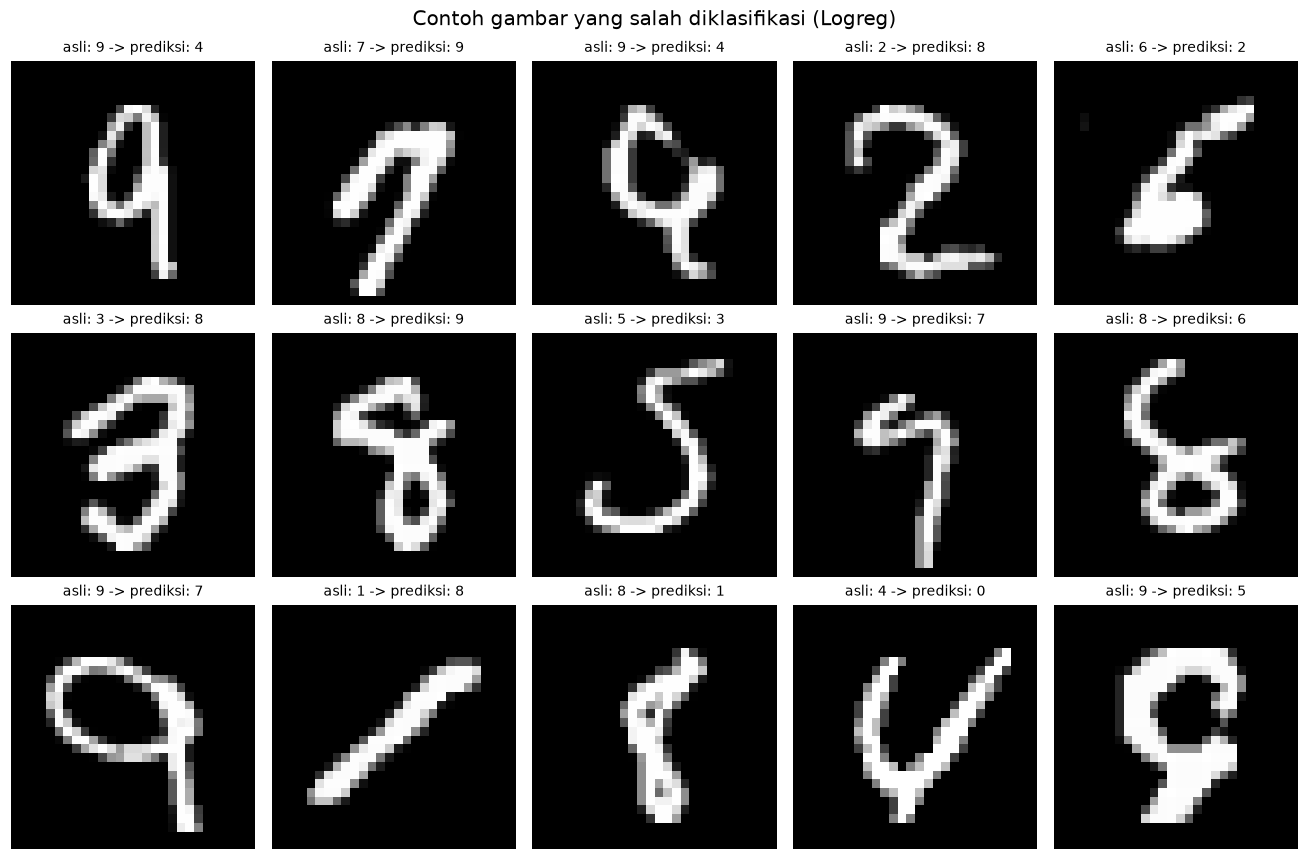

In [44]:
salah_id = np.where(y_pred_logreg != y_test)[0]
print(f"Total salah: {len(salah_id)} dari {len(y_test)} ({len(salah_id)/len(y_test):.1%})")

n_tampil = 15
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for ax, it in zip(axes.ravel(), salah_id[:n_tampil]):
    ax.imshow(X_test[it].reshape(28, 28), cmap='gray')
    ax.set_title(f"asli: {y_test[it]} -> prediksi: {y_pred_logreg[it]}", fontsize=9)
    ax.axis('off')

plt.suptitle("Contoh gambar yang salah diklasifikasi (Logreg)", fontsize=13)
plt.tight_layout()
plt.show()

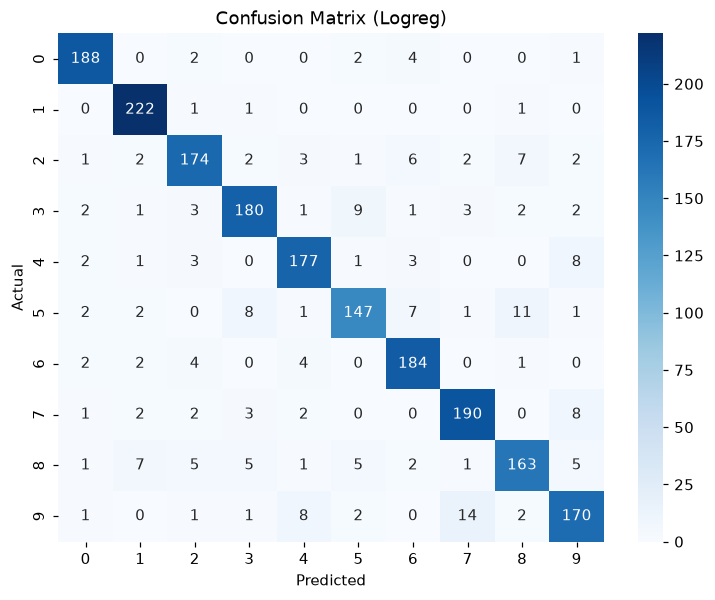

In [45]:
cm = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Logreg)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 2.4 Ringkasan & Perbandingan dengan KNN

In [46]:
from sklearn.metrics import classification_report
report_knn = classification_report(y_test, y_pred_knn)
print("Classification Report (KNN):\n", report_knn)

report_logreg = classification_report(y_test, y_pred_logreg)
print("Classification Report (Logreg):\n", report_logreg)

Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       197
           1       0.94      1.00      0.97       225
           2       0.94      0.93      0.94       200
           3       0.95      0.91      0.93       204
           4       0.94      0.94      0.94       195
           5       0.94      0.93      0.94       180
           6       0.95      0.98      0.97       197
           7       0.94      0.98      0.96       208
           8       0.97      0.90      0.94       195
           9       0.93      0.91      0.92       199

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000

Classification Report (Logreg):
               precision    recall  f1-score   support

           0       0.94      0.95      0.95       197
           1       0.93      0.99      0.96       225
           2   

In [47]:
df_hasil = pd.DataFrame(hasil).T
df_hasil = df_hasil.rename(columns={
    'akurasi': 'Akurasi',
    'waktu_train': 'Waktu Training (s)',
    'waktu_predict': 'Waktu Prediksi (s)'
})
print(df_hasil)

                     Akurasi  Waktu Training (s)  Waktu Prediksi (s)
Dummy                 0.1125                 NaN                 NaN
KNN (k=3)             0.9475            0.002732            0.103782
Logistic Regression   0.8975            8.303806            0.002105


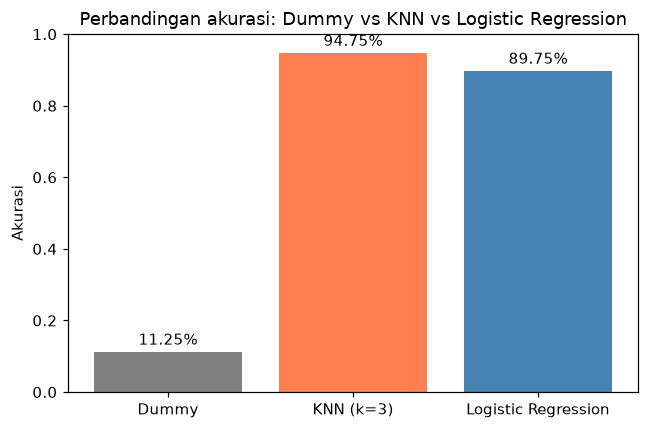

In [48]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_hasil.index, df_hasil['Akurasi'], color=['gray', 'coral', 'steelblue'])
ax.set_ylabel("Akurasi")
ax.set_ylim(0, 1)
ax.set_title("Perbandingan akurasi: Dummy vs KNN vs Logistic Regression")
for i, v in enumerate(df_hasil['Akurasi']):
    ax.text(i, v + 0.02, f"{v:.2%}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Kesimpulan

Secara **akurasi**, KNN (k=3) mencapai akurasi 94.75%, sedangkan Logistic Regression 89.75% (selisih sekitar 5 poin). KNN unggul karena tidak membuat asumsi apa pun tentang bentuk decision boundary (cukup mengandalkan kemiripan jarak antar gambar), sementara Logreg membatasi dirinya pada decision boundary **linear** di ruang 784 dimensi pixel.

Pada **waktu training vs prediksi**, Polanya berkebalikan:
- KNN adalah *lazy learner*. `fit()` hanya menyimpan data, tapi `predict()` harus menghitung jarak ke seluruh 8000 data latih untuk tiap sampel.
- Logreg harus mengoptimasi bobotnya secara iteratif saat `fit()`, tapi begitu weight final didapat, `predict()` tinggal mengalikan matriks sederhana, jauh lebih cepat dari KNN.

**Analisis kesalahan:** Dari classification report, penurunan performa Logreg paling terasa pada digit dengan bentuk kompleks/bervariasi seperti 5, 8, 9, dan 2 (recall turun 6-11 poin dibanding KNN), sementara digit dengan bentuk sederhana dan konsisten seperti 1 nyaris tidak terpengaruh (recall 99% vs 100%).

Confusion matrix menunjukkan digit 5 pada Logreg paling sering (11 kali) tertukar menjadi 8, dua digit yang secara visual memang punya lengkungan bawah yang mirip. Ini konsisten dengan keterbatasan model linear: bentuk tulisan tangan yang mirip secara visual butuh decision boundary yang melengkung untuk dipisahkan dengan baik, bukan hanya kombinasi linear dari tiap pixel.

**Trade off:** KNN lebih akurat untuk data gambar seperti ini karena fleksibel terhadap pola non-linear, tapi mahal saat inference sehingga kurang cocok untuk aplikasi real-time berskala besar. Logreg lebih ringan dan sangat cepat saat prediksi, namun akurasinya dibatasi oleh asumsi linearitas terhadap data yang secara alami tidak linear.

## We Draw

In [49]:
import gradio as gr
from PIL import Image

In [50]:
def prediksi_gradio(gambar):
    if gambar is None:
        return "Gambar dulu sebuah digit di kanvas."

    if isinstance(gambar, dict):
        gambar = gambar.get('composite')
        if gambar is None:
            return "Gambar tidak terbaca, coba gambar ulang."

    img = Image.fromarray(gambar).convert('L').resize((28, 28), Image.LANCZOS)
    arr = np.array(img).astype(np.float64) / 255.0

    x_input = arr.flatten().reshape(1, -1)
    pred_knn = knn.predict(x_input)[0]
    proba = knn.predict_proba(x_input)[0]

    return f"Prediksi KNN: {pred_knn}  (suara tetangga untuk digit ini: {proba[pred_knn]:.0%})"

In [51]:
css_kustom = """
#kanvas_gambar {
    display: flex !important;
    justify-content: center !important;
    align-items: center !important;
}
#kanvas_gambar > div {
    margin: 0 auto !important;
}
"""

def buat_kanvas_kosong():
    return Image.new('RGB', (280, 280), (0, 0, 0))

with gr.Blocks() as demo:
    gr.Markdown("### Tes model KNN dengan gambar tangan")
    gr.Markdown("Gambar satu digit (0-9) dengan warna putih, lalu klik Submit.")

    with gr.Row():
        sketch = gr.Sketchpad(
            type="numpy",
            value=buat_kanvas_kosong(),
            brush=gr.Brush(colors=["#FFFFFF"], color_mode="fixed", default_size=18),
            canvas_size=(280, 280),
            elem_id="kanvas_gambar"
        )
        output = gr.Textbox(label="Hasil prediksi")

    with gr.Row():
        tombol_submit = gr.Button("Submit", variant="primary")
        tombol_clear = gr.Button("Clear")

    tombol_submit.click(fn=prediksi_gradio, inputs=sketch, outputs=output)
    tombol_clear.click(fn=buat_kanvas_kosong, inputs=None, outputs=sketch)

# demo.launch(css=css_kustom)

In [52]:
demo.close()